# The rasterio Raster Workflow

This page runs end to end: open and inspect a GeoTIFF, reproject it to an
equal-area projection, rasterize a vector layer onto the same grid, overlay the two,
and finish with a small cartopy projection gallery.

```{admonition} This page is a runnable notebook
:class: tip
You can **read** the code and results right here. To **run** it yourself, click the
launch button (the 🚀 rocket / *"Open in Colab"*) at the top of the page — it opens this
exact notebook in Google Colab, no local install needed.
```


## 1 · Setup and data

This notebook includes a hidden setup cell so the Colab version can install the
geospatial libraries and fetch the sample data automatically. On the website, the setup
details are hidden so we can start with the raster workflow itself.


In [1]:
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Colab starts empty: install the libraries it doesn't ship, then fetch the data.
    !pip -q install rasterio geopandas cartopy
    import urllib.request
    # Data files are fetched from this repository on GitHub (raw content).
    BASE = "https://raw.githubusercontent.com/tongyuanwu/spatial-tutorial/main/book/data"
    os.makedirs("data/world_map", exist_ok=True)
    for f in ["NE2_110M_SR_W.tif",
              "world_map/world_map.shp", "world_map/world_map.shx",
              "world_map/world_map.dbf", "world_map/world_map.prj"]:
        urllib.request.urlretrieve(f"{BASE}/{f}", f"data/{f}")

def find_data_dir(start=None):
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").is_dir():
            return p / "data"
    return Path("data")

DATA_DIR = find_data_dir()
print("Using DATA_DIR =", DATA_DIR)

In [2]:
import numpy as np
import rasterio as rio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
from rasterio.features import rasterize
from rasterio.transform import array_bounds
import geopandas as gpd
from matplotlib import pyplot as plt
import cartopy.crs as ccrs

## 2 · Open and inspect a raster

`rasterio.open` gives a dataset handle. Its properties tell you everything about the
grid before you read a single pixel: how many bands, the size in pixels, the data type,
the coordinate reference system (CRS), the affine transform, and the geographic bounds.


In [3]:
src = rio.open(DATA_DIR / "NE2_110M_SR_W.tif")

print("bands     :", src.count)
print("size      :", src.width, "x", src.height, "(cols x rows)")
print("dtype     :", src.dtypes)
print("CRS       :", src.crs.to_string())
print("transform :", src.transform)
print("bounds    :", src.bounds)

bands     : 3
size      : 3600 x 1800 (cols x rows)
dtype     : ('uint8', 'uint8', 'uint8')
CRS       : EPSG:4326
transform : | 0.10, 0.00,-180.00|
| 0.00,-0.10, 90.00|
| 0.00, 0.00, 1.00|
bounds    : BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)


## 3 · View the imagery

The Natural Earth II image has three bands (R, G, B). rasterio reads it as
`(band, row, col)`; matplotlib's `imshow` wants `(row, col, band)`, so we transpose.


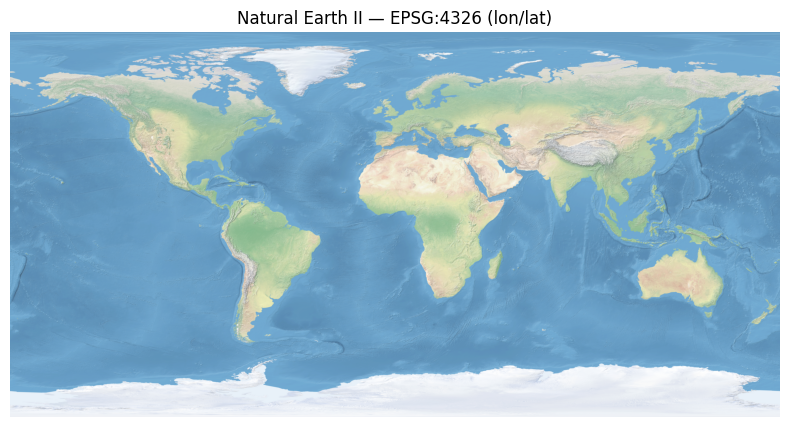

In [4]:
rgb = src.read()                       # shape (3, H, W)
plt.figure(figsize=(10, 5))
plt.imshow(rgb.transpose(1, 2, 0))     # -> (H, W, 3)
plt.title("Natural Earth II — EPSG:4326 (lon/lat)")
plt.axis("off")
plt.show()

## 4 · Reproject to an equal-area projection (Eckert IV)

Lon/lat (EPSG:4326) badly distorts area near the poles. For global thematic maps we
prefer an **equal-area** projection such as Eckert IV (`ESRI:54012`). `calculate_default_transform`
works out the destination grid; `reproject` warps each band onto it.


In [5]:
dst_crs = "ESRI:54012"   # Eckert IV (equal-area)

transform_dst, w_dst, h_dst = calculate_default_transform(
    src.crs, dst_crs, src.width, src.height, *src.bounds)

reprojected = np.zeros((src.count, h_dst, w_dst), dtype="uint8")
for b in range(src.count):
    reproject(
        source=src.read(b + 1),
        destination=reprojected[b],
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=transform_dst, dst_crs=dst_crs,
        resampling=Resampling.bilinear,
    )

print("reprojected grid:", w_dst, "x", h_dst)

reprojected grid: 5692 x 2846


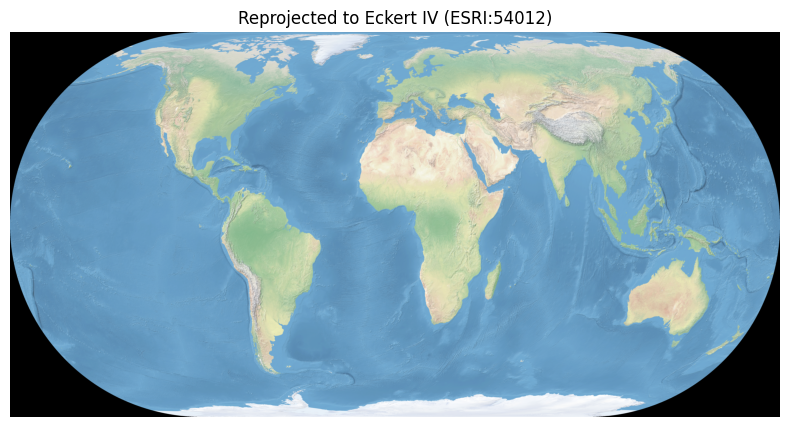

In [6]:
plt.figure(figsize=(10, 5))
plt.imshow(reprojected.transpose(1, 2, 0))
plt.title("Reprojected to Eckert IV (ESRI:54012)")
plt.axis("off")
plt.show()

## 5 · Rasterize a vector layer and overlay it

We load country polygons, reproject them to the **same** CRS, then `rasterize` them onto
the **same** grid (each country gets a unique integer). Sharing one `transform` lets us
overlay the raster basemap, the rasterized countries, and the vector outlines so they
line up exactly. `extent` places the image in real-world coordinates.


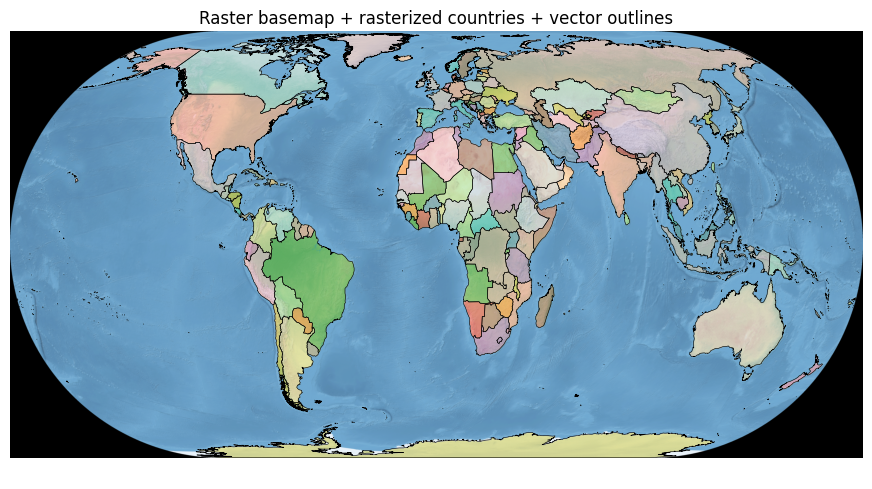

In [7]:
world = gpd.read_file(DATA_DIR / "world_map" / "world_map.shp").to_crs(dst_crs)

shapes = [(geom, i + 1) for i, geom in enumerate(world.geometry) if geom is not None]
country_raster = rasterize(
    shapes, out_shape=(h_dst, w_dst),
    transform=transform_dst, fill=0, dtype="int32",
)

left, bottom, right, top = array_bounds(h_dst, w_dst, transform_dst)
extent = [left, right, bottom, top]

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(reprojected.transpose(1, 2, 0), extent=extent, origin="upper")
ax.imshow(np.where(country_raster > 0, country_raster, np.nan),
          extent=extent, origin="upper", cmap="tab20", alpha=0.45)
world.boundary.plot(ax=ax, color="black", lw=0.4)
ax.set_title("Raster basemap + rasterized countries + vector outlines")
ax.axis("off")
plt.show()

## 6 · A projection gallery with cartopy

cartopy attaches a projection to an axis. `stock_img` draws a built-in basemap and
`gridlines` adds the graticule. (Coastlines download Natural Earth data on first use, so
we draw them only when a network connection is available.)


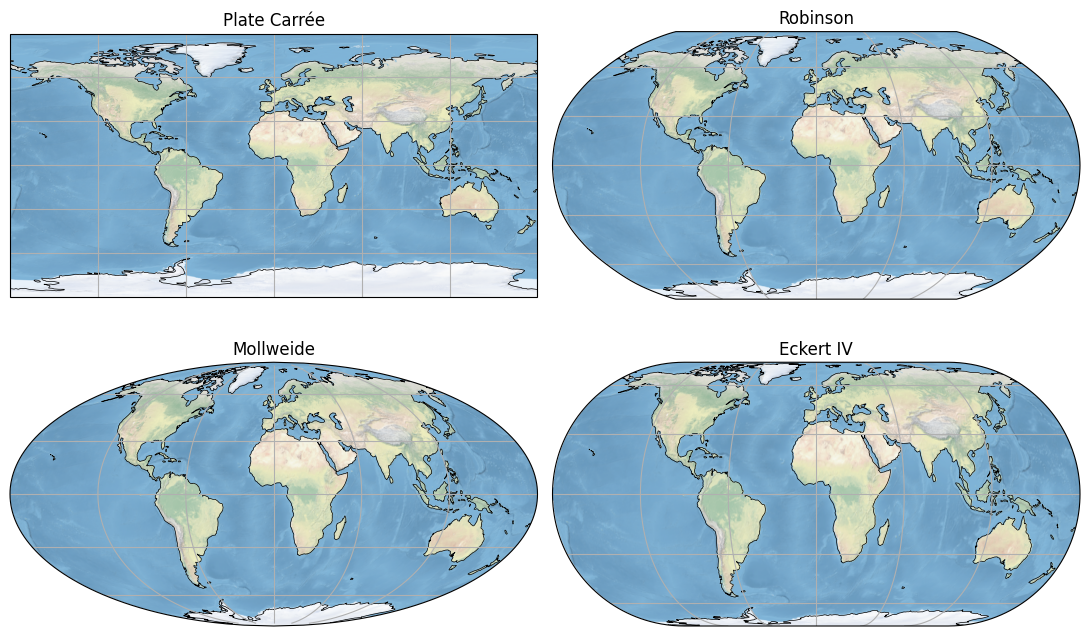

In [8]:
projections = [
    (ccrs.PlateCarree(), "Plate Carrée"),
    (ccrs.Robinson(),    "Robinson"),
    (ccrs.Mollweide(),   "Mollweide"),
    (ccrs.EckertIV(),    "Eckert IV"),
]

fig = plt.figure(figsize=(11, 7))
for i, (proj, name) in enumerate(projections, start=1):
    ax = fig.add_subplot(2, 2, i, projection=proj)
    ax.stock_img()
    ax.gridlines()
    try:
        ax.coastlines(lw=0.5)
    except Exception:
        pass            # no network — skip coastline download
    ax.set_title(name)
fig.tight_layout()
plt.show()

```{admonition} Deliverable
:class: note
You now have: a reprojected Eckert IV array in memory, a rasterized country layer on the
same grid, an aligned raster+vector overlay, and a four-projection cartopy gallery — the
full rasterio workflow in one notebook.
```
